# __<center>  MODELO PARA INSPEÇÃO DE PAINÉIS SOLARES<center>__

<center><center>

BANCO DE DADOS: https://www.kaggle.com/datasets/pythonafroz/solar-panel-images

MODELO PROPOSTO: Adaptação de https://chrischow.github.io/dataandstuff/2020-09-05-deep-learning-for-aircraft-recognition/ e https://www.kaggle.com/code/jeffaudi/aircraft-detection-with-yolov5

Inicialmente, propõe-se aplicar um modelo de visão computacional originalmente destinado a identificar aeronaves, em um problema de inspeção de painéis solares.

# PRIMEIRA PARTE

TREINO/VALIDAÇÃO/TESTE COM IMAGENS REAIS

# Passo 01: Instalando bibliotecas

In [ ]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
pip install tensorflow pillow tabulate


# Passo 02: Extraindo os dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Lista com os caminhos dos arquivos zip
zip_files = [
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/coco_passaro.zip",
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/no_defects.zip",
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/sujeira.zip"
]

# Pasta base de extração
extract_base = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000"

# Loop para descompactar todos os arquivos
for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        extract_path = os.path.splitext(zip_path)[0]  # Remove .zip para nomear pasta
        zip_ref.extractall(extract_path)
        print(f"Arquivo descompactado em: {extract_path}")


Arquivo descompactado em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/coco_passaro
Arquivo descompactado em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/no_defects
Arquivo descompactado em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/sujeira


In [ ]:
import os

# Lista dos diretórios que serão contabilizados
directories = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Bird-drop',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Clean',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Dusty'
]

# Para cada diretório, percorre recursivamente e soma o número de arquivos
for d in directories:
    count = 0
    for root, dirs, files in os.walk(d):
        count += len(files)
    print(f"{d}: {count} arquivos")


/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Bird-drop: 192 arquivos
/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Clean: 194 arquivos
/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Dusty: 191 arquivos


FAZER:

TREINO/VALID

1. Bird: 150 arquivos
2. Clean: 150 arquivos
3. Dust: 150 arquivos

TESTE

1. Bird: 42 arquivos
2. Clean: 44 arquivos
3. Dust: 41 arquivos


# Passo 03: Dividindo o banco de dados

In [ ]:
import os
import shutil
import random

# Diretórios onde estão as imagens originais
directories = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Bird-drop',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Clean',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/Dusty'
]

# Definindo os diretórios de saída para TREINO/VALID e TESTE
output_train_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID'
output_test = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE'

# Classes (os nomes extraídos dos arquivos devem ser 'Bird', 'Clean' e 'Dust')
classes = ['Bird', 'Clean', 'Dust']

# Cria as pastas de saída para cada classe dentro de TREINO/VALID e TESTE
for cls in classes:
    os.makedirs(os.path.join(output_train_valid, cls), exist_ok=True)
    os.makedirs(os.path.join(output_test, cls), exist_ok=True)

# Dicionário para armazenar os caminhos dos arquivos por classe
files_by_class = {cls: [] for cls in classes}

# Percorre cada diretório para coletar os arquivos de imagem
for directory in directories:
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpeg', '.jpg')):
                # Assume que o nome do arquivo está no formato "Classe (n).jpeg"
                class_name = file.split()[0]
                if class_name in files_by_class:
                    files_by_class[class_name].append(os.path.join(root, file))

# Para cada classe, embaralha e divide os arquivos: 150 para TREINO/VALID e o restante para TESTE
for cls in classes:
    random.shuffle(files_by_class[cls])
    train_valid_files = files_by_class[cls][:150]
    test_files = files_by_class[cls][150:]

    # Copia os arquivos para o diretório de TREINO/VALID
    for file_path in train_valid_files:
        shutil.copy2(file_path, os.path.join(output_train_valid, cls))

    # Copia os arquivos para o diretório de TESTE
    for file_path in test_files:
        shutil.copy2(file_path, os.path.join(output_test, cls))

    print(f"{cls}: TREINO/VALID = {len(train_valid_files)} arquivos, TESTE = {len(test_files)} arquivos")


Bird: TREINO/VALID = 150 arquivos, TESTE = 41 arquivos
Clean: TREINO/VALID = 150 arquivos, TESTE = 42 arquivos
Dust: TREINO/VALID = 150 arquivos, TESTE = 40 arquivos


FAZENDO AS CLASSES CHEGAREM A 1000 IMAGENS CADA UMA USANDO DATA AUGMENTATION.

In [ ]:
import os
import shutil
import random
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Diretório de entrada (imagens originais do conjunto TREINO)
input_train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID'
# Diretório de saída para as imagens aumentadas
output_aug_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG'

classes = ['Bird', 'Clean', 'Dust']

# Define os parâmetros de data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,         # Rotaciona até 30 graus
    width_shift_range=0.1,     # Deslocamento horizontal de até 10%
    height_shift_range=0.1,    # Deslocamento vertical de até 10%
    shear_range=0.2,           # Cisalhamento
    zoom_range=0.2,            # Zoom de até 20%
    horizontal_flip=True,      # Inverte horizontalmente
    fill_mode='nearest'        # Preenche pixels vazios com o valor mais próximo
)

for cls in classes:
    input_dir = os.path.join(input_train_dir, cls)
    output_dir = os.path.join(output_aug_dir, cls)
    os.makedirs(output_dir, exist_ok=True)

    # Lista as imagens originais da classe
    images = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpeg', '.jpg'))]

    # Primeiro, copia as imagens originais para o diretório de saída
    count = 0
    for img_name in images:
        src_path = os.path.join(input_dir, img_name)
        dst_path = os.path.join(output_dir, img_name)
        shutil.copy2(src_path, dst_path)
        count += 1

    # Enquanto o total de imagens for menor que 1000, gera imagens aumentadas
    while count < 1000:
        # Seleciona uma imagem aleatória dentre as originais
        img_name = random.choice(images)
        img_path = os.path.join(input_dir, img_name)

        # Carrega a imagem e converte para array
        img = load_img(img_path)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        # Gera uma imagem aumentada
        aug_iter = datagen.flow(x, batch_size=1)
        aug_img = next(aug_iter)[0].astype(np.uint8)

        # Salva a imagem aumentada com um nome único
        aug_img_name = f"{os.path.splitext(img_name)[0]}_aug_{count}.jpeg"
        save_img(os.path.join(output_dir, aug_img_name), aug_img)
        count += 1

    print(f"{cls}: {count} imagens salvas em {output_dir}")


Bird: 1000 imagens salvas em /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird
Clean: 1000 imagens salvas em /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Clean
Dust: 1000 imagens salvas em /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Dust


In [ ]:
import os

# Defina os diretórios de origem
source_dirs = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Clean',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Dust'
]

# Função para contar os arquivos em cada diretório
def count_files_in_directories(directories):
    file_counts = {}
    for dir_path in directories:
        if os.path.exists(dir_path):
            file_counts[dir_path] = len([f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))])
        else:
            file_counts[dir_path] = "Directory does not exist"
    return file_counts

# Contar os arquivos
file_counts = count_files_in_directories(source_dirs)

# Exibir os resultados
for dir_path, count in file_counts.items():
    print(f"{dir_path}: {count} arquivos")


/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird: 1000 arquivos
/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Clean: 1000 arquivos
/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Dust: 1000 arquivos


JUNTANDO AS IMAGENS EM UMA ÚNICA PASTA = ALL IMAGES

In [ ]:
import os
import shutil

# Diretórios de origem com as imagens aumentadas
source_dirs = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Clean',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Dust'
]

# Diretório de destino onde todas as imagens serão copiadas
destination_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/'
os.makedirs(destination_dir, exist_ok=True)

# Percorre cada diretório de origem e copia os arquivos para o diretório de destino
for src_dir in source_dirs:
    for filename in os.listdir(src_dir):
        # Considera apenas arquivos com extensão JPEG ou JPG
        if filename.lower().endswith(('.jpeg', '.jpg')):
            src_path = os.path.join(src_dir, filename)
            dest_path = os.path.join(destination_dir, filename)

            # Se um arquivo com o mesmo nome já existir, adiciona um sufixo para evitar sobrescrita
            base, ext = os.path.splitext(filename)
            counter = 1
            while os.path.exists(dest_path):
                dest_path = os.path.join(destination_dir, f"{base}_{counter}{ext}")
                counter += 1

            shutil.copy2(src_path, dest_path)
            print(f"Copiado: {src_path} -> {dest_path}")


Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird/Bird (113).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/Bird (113).jpg
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird/Bird (136).JPG -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/Bird (136).JPG
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird/Bird (167).JPG -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/Bird (167).JPG
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID_AUG/Bird/Bird (87).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/Bird (87).jpg
Copiado: /content/drive/MyDrive/Projeto - 

In [ ]:
import os

destination_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/'

count = 0

# Itera sobre os arquivos no diretório e conta aqueles com as extensões desejadas
for filename in os.listdir(destination_dir):
    if filename.lower().endswith(('.jpeg', '.jpg')):
        count += 1

print(f"Total de imagens: {count}")


Total de imagens: 3000


In [ ]:
import os
import shutil
import random

# Diretório de origem com todas as imagens
source_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/TREINO_VALID_AUG/'


# Diretórios de destino para TREINO (80%) e VALID (20%)
train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
valid_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'

# Cria os diretórios de destino se não existirem
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)

# Lista das classes, conforme os nomes presentes nos arquivos
classes = ['Bird', 'Clean', 'Dust']

# Dicionário para agrupar os arquivos por classe
files_by_class = {cls: [] for cls in classes}

# Itera sobre os arquivos no diretório fonte
for filename in os.listdir(source_dir):
    if filename.lower().endswith(('.jpeg', '.jpg')):
        # Verifica a classe a partir do nome do arquivo (caso insensível a maiúsculas/minúsculas)
        for cls in classes:
            if cls.lower() in filename.lower():
                files_by_class[cls].append(filename)
                break

# Para cada classe, embaralha e divide os arquivos em 80% TREINO e 20% VALID
for cls in classes:
    file_list = files_by_class[cls]
    random.shuffle(file_list)
    total = len(file_list)
    train_count = int(total * 0.8)  # 80% para treino
    train_files = file_list[:train_count]
    valid_files = file_list[train_count:]

    # Copia os arquivos para o diretório de TREINO
    for file in train_files:
        src_path = os.path.join(source_dir, file)
        dest_path = os.path.join(train_dir, file)
        shutil.copy2(src_path, dest_path)

    # Copia os arquivos para o diretório de VALID
    for file in valid_files:
        src_path = os.path.join(source_dir, file)
        dest_path = os.path.join(valid_dir, file)
        shutil.copy2(src_path, dest_path)

    print(f"{cls}: Total = {total}, TREINO = {len(train_files)}, VALID = {len(valid_files)}")


Bird: Total = 1000, TREINO = 800, VALID = 200
Clean: Total = 1000, TREINO = 800, VALID = 200
Dust: Total = 1000, TREINO = 800, VALID = 200


In [ ]:
import os

# Diretórios de interesse
train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
valid_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'

# Lista das classes a serem identificadas nos nomes dos arquivos
classes = ['Bird', 'Clean', 'Dust']

def count_images_by_class(directory, classes):
    counts = {cls: 0 for cls in classes}
    for filename in os.listdir(directory):
        if filename.lower().endswith(('.jpeg', '.jpg')):
            for cls in classes:
                if cls.lower() in filename.lower():
                    counts[cls] += 1
                    break
    return counts

# Contagem para cada diretório
train_counts = count_images_by_class(train_dir, classes)
valid_counts = count_images_by_class(valid_dir, classes)

# Impressão dos resultados
print("Contagem de imagens em PARA_TREINO:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nContagem de imagens em PARA_VALID:")
for cls, count in valid_counts.items():
    print(f"{cls}: {count}")


Contagem de imagens em PARA_TREINO:
Bird: 800
Clean: 800
Dust: 800

Contagem de imagens em PARA_VALID:
Bird: 200
Clean: 200
Dust: 200


# Passo 04: Treinar o Modelo


In [ ]:
import os

output_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
output_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'

def count_files_in_dir(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

train_count = count_files_in_dir(output_train)
valid_count = count_files_in_dir(output_valid)

print("Número de arquivos em TREINO:", train_count)
print("Número de arquivos em VALID:", valid_count)


Número de arquivos em TREINO: 2400
Número de arquivos em VALID: 600


In [ ]:
import os
import shutil

# Diretórios de origem
source_dirs = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Clean',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Dust'
]

# Diretório de destino
destination_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'
os.makedirs(destination_dir, exist_ok=True)

# Extensões válidas
valid_extensions = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')

for src_dir in source_dirs:
    for filename in os.listdir(src_dir):
        if filename.lower().endswith(valid_extensions):
            src_path = os.path.join(src_dir, filename)
            dest_path = os.path.join(destination_dir, filename)

            # Se já existir um arquivo com o mesmo nome, adiciona um sufixo para evitar sobrescrita
            base, ext = os.path.splitext(filename)
            counter = 1
            while os.path.exists(dest_path):
                dest_path = os.path.join(destination_dir, f"{base}_{counter}{ext}")
                counter += 1

            shutil.copy2(src_path, dest_path)
            print(f"Copiado: {src_path} -> {dest_path}")


Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird/Bird (176).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE/Bird (176).jpg
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird/Bird (189).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE/Bird (189).jpg
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird/Bird (102).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE/Bird (102).jpg
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird/Bird (22).jpg -> /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE/Bird (22).jpg
Copiado: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TESTE/Bird/B

In [ ]:
import os

destination_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'
valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
count = len([f for f in os.listdir(destination_dir) if f.lower().endswith(valid_ext)])
print("Total de imagens em TESTE_GERAL:", count)


Total de imagens em TESTE_GERAL: 123


In [ ]:
import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Diretórios onde as imagens estão armazenadas (imagens diretamente na pasta)
dest_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
dest_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'
dest_test  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'


# Parâmetros
image_size = (70, 70)
batch_size = 32

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo a partir do nome do arquivo.
    Exemplo: "Bird (1).jpeg" -> "Bird"
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    # Considera a primeira palavra como o rótulo
    label_str = tf.strings.split(file_name, ' ')[0]
    label_index = table.lookup(label_str)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    """
    Lê, decodifica, redimensiona, normaliza a imagem e extrai o rótulo.
    """
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0  # Normalização
    return image, label

def create_dataset(directory):
    """
    Cria um dataset a partir de todos os arquivos de imagem encontrados no diretório informado.
    """
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    # Filtra apenas arquivos com extensões válidas
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Criação dos datasets de treino, validação e teste.
# Utilizamos .repeat() para garantir que o dataset não se esgote durante o treinamento.
train_dataset = create_dataset(dest_train).repeat()
valid_dataset = create_dataset(dest_valid).repeat()
test_dataset  = create_dataset(dest_test)  # Para teste, não é necessário repetir

# Função para contar as imagens em um diretório (imagens diretamente na pasta)
def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

n_train = count_images(dest_train)
n_valid = count_images(dest_valid)

# Definindo os steps com base na quantidade de imagens e no batch_size
steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print("Total de imagens de treino:", n_train)
print("Total de imagens de validação:", n_valid)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Classes:", class_names)

# Construção do modelo
model = Sequential()

# Bloco 1
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01), input_shape=(70, 70, 3)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 2
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 3
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 4
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Camada densa
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00004),
    metrics=['accuracy']
)

model.summary()

# Treinamento do modelo com steps_per_epoch e validation_steps definidos
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_dataset,
    validation_steps=validation_steps,
    epochs=50
)

# Função para plotar a evolução do treinamento usando Plotly
def plot_training_history(history):
    if 'accuracy' in history.history:
        acc_key = 'accuracy'
        val_acc_key = 'val_accuracy'
    else:
        acc_key = list(history.history.keys())[1]
        val_acc_key = f'val_{acc_key}'

    epochs = list(range(1, len(history.history['loss']) + 1))

    # Gráfico de Acurácia
    fig_acc = go.Figure()
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[acc_key],
                                 mode='lines+markers', name='Acurácia Treino'))
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[val_acc_key],
                                 mode='lines+markers', name='Acurácia Validação'))
    fig_acc.update_layout(title='Evolução da Acurácia por Época',
                          xaxis_title='Época',
                          yaxis_title='Acurácia',
                          template='plotly_dark')

    # Gráfico de Perda
    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['loss'],
                                  mode='lines+markers', name='Perda Treino'))
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'],
                                  mode='lines+markers', name='Perda Validação'))
    fig_loss.update_layout(title='Evolução da Perda por Época',
                           xaxis_title='Época',
                           yaxis_title='Perda',
                           template='white_dark')

    fig_acc.show()
    fig_loss.show()

# Plotar os gráficos de evolução do treinamento
plot_training_history(history)

# SALVAR O MODELO TREINADO
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5'

model.save(model_save_path)
print(f"Modelo salvo em: {model_save_path}")


Total de imagens de treino: 2400
Total de imagens de validação: 600
Steps per epoch: 75
Validation steps: 18
Classes: ['Bird', 'Clean', 'Dust']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 70, 70, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 70, 70, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 70, 70, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 35, 35, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 35, 35, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 35, 35, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 35, 35, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 35, 35, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 17, 17, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 17, 17, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 17, 17, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 17, 17, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 4, 4, 512)           │           2,0

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6213 - loss: 26.3783 - val_accuracy: 0.3385 - val_loss: 26.1529
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.6517 - loss: 25.9323 - val_accuracy: 0.3333 - val_loss: 25.9929
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7455 - loss: 25.3728 - val_accuracy: 0.3420 - val_loss: 25.9450
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.7794 - loss: 25.0159 - val_accuracy: 0.3385 - val_loss: 25.9961
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8094 - loss: 24.6929 - val_accuracy: 0.3351 - val_loss: 26.4659
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8430 - loss: 24.3509 - val_accuracy: 0.3368 - val_loss: 26.3156
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8831 - loss: 23.9598 - val_accuracy: 0.3420 - val_loss: 25.5664
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8839 - loss: 23.6339 - val_accur

Modelo salvo em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
solar_panel_inspection_cnn.py
───────────────────────────────────────
Loads images from train/validation/test folders, trains a CNN to classify
into Bird, Clean, Dust, and plots training history with English labels.
"""

import os
import random
import numpy as np
import tensorflow as tf
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, BatchNormalization,
    Flatten, Dense, Dropout
)
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam

# Directories
TRAIN_DIR = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
VALID_DIR = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'
TEST_DIR  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'

# Parameters
IMAGE_SIZE    = (70, 70)
BATCH_SIZE    = 32
CLASS_NAMES   = ["Bird", "Clean", "Dust"]
NUM_CLASSES   = len(CLASS_NAMES)
LEARNING_RATE = 4e-5
EPOCHS        = 100

# Build a lookup table for labels
label_table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(CLASS_NAMES),
        values=tf.constant(list(range(NUM_CLASSES)), dtype=tf.int32),
    ),
    default_value=-1
)

def extract_label(file_path):
    """Extract the class label from the filename."""
    filename = tf.strings.split(file_path, os.sep)[-1]
    label_str = tf.strings.split(filename, ' ')[0]
    idx = label_table.lookup(label_str)
    return tf.one_hot(idx, depth=NUM_CLASSES)

def load_and_preprocess(path):
    """Load image, resize, normalize, and extract label."""
    label = extract_label(path)
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0
    return img, label

def make_dataset(directory, shuffle=True, repeat=False):
    """Create tf.data.Dataset from image files in a directory."""
    files = tf.data.Dataset.list_files(os.path.join(directory, '*.*'), shuffle=False)
    valid_ext = tf.constant(['.jpeg','.jpg','.png','.bmp','.gif'])
    files = files.filter(lambda x: tf.reduce_any(
        tf.map_fn(lambda ext: tf.strings.regex_full_match(x, '.*' + ext),
                  valid_ext, dtype=tf.bool)
    ))
    ds = files.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Count images
def count_images(directory):
    ext = ('.jpeg','.jpg','.png','.bmp','.gif')
    return sum(1 for f in os.listdir(directory) if f.lower().endswith(ext))

n_train = count_images(TRAIN_DIR)
n_valid = count_images(VALID_DIR)
steps_per_epoch    = n_train // BATCH_SIZE
validation_steps   = n_valid // BATCH_SIZE

print(f"Training images: {n_train}, Validation images: {n_valid}")
print(f"Steps/epoch: {steps_per_epoch}, Validation steps: {validation_steps}")
print(f"Classes: {CLASS_NAMES}")

# Create datasets
train_ds = make_dataset(TRAIN_DIR, shuffle=True, repeat=True)
valid_ds = make_dataset(VALID_DIR, shuffle=True, repeat=True)
test_ds  = make_dataset(TEST_DIR, shuffle=False, repeat=False)

# Build CNN model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01), input_shape=(*IMAGE_SIZE,3)),
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    Conv2D(256, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    Conv2D(512, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same',
           kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

model.summary()

# Train
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_ds,
    validation_steps=validation_steps,
    epochs=EPOCHS
)

# Plot training history with English labels and plotly_white template
def plot_history(hist):
    epochs = list(range(1, len(hist.history['loss']) + 1))

    # Accuracy
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(
        x=epochs, y=hist.history['accuracy'],
        mode='lines+markers', name='Train Accuracy'
    ))
    fig1.add_trace(go.Scatter(
        x=epochs, y=hist.history['val_accuracy'],
        mode='lines+markers', name='Validation Accuracy'
    ))
    fig1.update_layout(
        title='Model Accuracy',
        xaxis_title='Epoch',
        yaxis_title='Accuracy',
        template='plotly_white'
    )

    # Loss
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(
        x=epochs, y=hist.history['loss'],
        mode='lines+markers', name='Train Loss'
    ))
    fig2.add_trace(go.Scatter(
        x=epochs, y=hist.history['val_loss'],
        mode='lines+markers', name='Validation Loss'
    ))
    fig2.update_layout(
        title='Model Loss',
        xaxis_title='Epoch',
        yaxis_title='Loss',
        template='plotly_white'
    )

    fig1.show()
    fig2.show()

plot_history(history)

# Save model
MODEL_PATH = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/model_trained_PART1.h5'
model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Training images: 2400, Validation images: 600
Steps/epoch: 75, Validation steps: 18
Classes: ['Bird', 'Clean', 'Dust']


Instructions for updating:
Use fn_output_signature instead
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.6210 - loss: 26.4014 - val_accuracy: 0.3299 - val_loss: 26.2204
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7359 - loss: 25.7590 - val_accuracy: 0.3351 - val_loss: 26.0771
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.7398 - loss: 25.4119 - val_accuracy: 0.3333 - val_loss: 25.9588
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7942 - loss: 25.0521 - val_accuracy: 0.3368 - val_loss: 26.0435
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8649 - loss: 24.6610 - val_accuracy: 0.3368 - val_loss: 26.3255
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8636 - loss: 24.3844 - val_accuracy: 0.3351 - val_loss: 26.0399
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9230 - loss: 23.9989 - val_accuracy: 0.3385 - val_loss: 26.0675
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9362 - loss: 23.6824 - v

Model saved to /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/model_trained_PART1.h5


In [ ]:
import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Diretórios onde as imagens estão armazenadas (imagens diretamente na pasta)
dest_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TREINO'
dest_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_VALID'
dest_test  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'


# Parâmetros
image_size = (70, 70)
batch_size = 32

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo a partir do nome do arquivo.
    Exemplo: "Bird (1).jpeg" -> "Bird"
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    # Considera a primeira palavra como o rótulo
    label_str = tf.strings.split(file_name, ' ')[0]
    label_index = table.lookup(label_str)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    """
    Lê, decodifica, redimensiona, normaliza a imagem e extrai o rótulo.
    """
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0  # Normalização
    return image, label

def create_dataset(directory):
    """
    Cria um dataset a partir de todos os arquivos de imagem encontrados no diretório informado.
    """
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    # Filtra apenas arquivos com extensões válidas
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Criação dos datasets de treino, validação e teste.
# Utilizamos .repeat() para garantir que o dataset não se esgote durante o treinamento.
train_dataset = create_dataset(dest_train).repeat()
valid_dataset = create_dataset(dest_valid).repeat()
test_dataset  = create_dataset(dest_test)  # Para teste, não é necessário repetir

# Função para contar as imagens em um diretório (imagens diretamente na pasta)
def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

n_train = count_images(dest_train)
n_valid = count_images(dest_valid)

# Definindo os steps com base na quantidade de imagens e no batch_size
steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print("Total de imagens de treino:", n_train)
print("Total de imagens de validação:", n_valid)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Classes:", class_names)

# Construção do modelo
model = Sequential()

# Bloco 1
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01), input_shape=(70, 70, 3)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 2
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 3
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 4
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(Conv2D(filters=512, kernel_size=(3,3), activation='relu', padding='same',
                 kernel_regularizer=L2(l2=0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Camada densa
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00004),
    metrics=['accuracy']
)

model.summary()

# Treinamento do modelo com steps_per_epoch e validation_steps definidos
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_dataset,
    validation_steps=validation_steps,
    epochs=100
)

# Função para plotar a evolução do treinamento usando Plotly
def plot_training_history(history):
    if 'accuracy' in history.history:
        acc_key = 'accuracy'
        val_acc_key = 'val_accuracy'
    else:
        acc_key = list(history.history.keys())[1]
        val_acc_key = f'val_{acc_key}'

    epochs = list(range(1, len(history.history['loss']) + 1))

    # Gráfico de Acurácia
    fig_acc = go.Figure()
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[acc_key],
                                 mode='lines+markers', name='Train Accuracy'))
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[val_acc_key],
                                 mode='lines+markers', name='Validation Accuracy'))
    fig_acc.update_layout(title='',
                          xaxis_title='Epoch',
                          yaxis_title='Accuracy',
                          template='plotly_white')

    # Gráfico de Perda
    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['loss'],
                                  mode='lines+markers', name='Train Loss'))
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'],
                                  mode='lines+markers', name='Validation Loss'))
    fig_loss.update_layout(title='',
                           xaxis_title='Epoch',
                           yaxis_title='Loss',
                           template='white_white')

    fig_acc.show()
    fig_loss.show()

# Plotar os gráficos de evolução do treinamento
plot_training_history(history)

# SALVAR O MODELO TREINADO
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5'

model.save(model_save_path)
print(f"Modelo salvo em: {model_save_path}")


TESTANDO

ENGLISH

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# --- Helper functions (must match training) ---

# Class definitions
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Lookup table for filename → index
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    label_str = tf.strings.split(file_name, ' ')[0]
    idx = table.lookup(label_str)
    return tf.one_hot(idx, depth=num_classes)

def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (70, 70))
    image = image / 255.0
    return image, label

def create_dataset(directory, batch_size=32):
    pattern = os.path.join(directory, '*')
    ds = tf.data.Dataset.list_files(pattern, shuffle=False)
    ds = ds.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# --- Load trained model ---
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5'
model = load_model(model_path)
print(f"Model loaded from: {model_path}")

# --- Prepare test dataset ---
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'
batch_size_test = 32
test_dataset = create_dataset(test_dir, batch_size=batch_size_test)

# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# --- Gather predictions and true labels ---
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Classification report ---
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# --- Plot confusion matrix with Plotly in English ---
fig_cm = go.Figure(data=go.Heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True,
    colorbar=dict(title='Count'),
    hovertemplate='Predicted: %{x}<br>True: %{y}<br>Count: %{z}<extra></extra>'
))

# Annotate cells
annotations = []
max_val = cm.max()
for i in range(len(class_names)):
    for j in range(len(class_names)):
        annotations.append(dict(
            text=str(cm[i][j]),
            x=class_names[j],
            y=class_names[i],
            xref='x1',
            yref='y1',
            showarrow=False,
            font=dict(
                color='white' if cm[i][j] > max_val/2 else 'black',
                size=14
            )
        ))

fig_cm.update_layout(
    title='Confusion Matrix – Test Set',
    xaxis=dict(title='Predicted Label'),
    yaxis=dict(title='True Label', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig_cm.show()


Model loaded from: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7555 - loss: 11.3118
Test Loss: 11.4973
Test Accuracy: 0.7143


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
Classification Report:
              precision    recall  f1-score   support

        Bird       0.76      0.74      0.75        38
       Clean       0.67      0.71      0.69        41
        Dust       0.72      0.70      0.71        40

    accuracy                           0.71       119
   macro avg       0.72      0.71      0.72       119
weighted avg       0.72      0.71      0.71       119

Confusion Matrix:
[[28  7  3]
 [ 4 29  8]
 [ 5  7 28]]


In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# --- Funções auxiliares (devem ser as mesmas utilizadas no treinamento) ---

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo a partir do nome do arquivo.
    Exemplo: "Bird (1).jpeg" -> "Bird"
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    label_str = tf.strings.split(file_name, ' ')[0]
    label_index = table.lookup(label_str)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    """
    Lê, decodifica, redimensiona, normaliza a imagem e extrai o rótulo.
    """
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (70, 70))
    image = image / 255.0
    return image, label

def create_dataset(directory, batch_size=32):
    """
    Cria um dataset a partir de todos os arquivos de imagem encontrados no diretório informado.
    """
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# --- Carregar o modelo treinado ---
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5'
model = load_model(model_path)
print(f"Modelo carregado de: {model_path}")

# --- Criar o dataset de teste ---
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'



batch_size_test = 32
test_dataset = create_dataset(test_dir, batch_size=batch_size_test)

# --- Avaliar o modelo ---
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Perda no conjunto de teste: {test_loss:.4f}")
print(f"Acurácia no conjunto de teste: {test_accuracy:.4f}")

# --- Coletar predições e rótulos verdadeiros ---
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Relatório de classificação ---
print("Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# --- Visualização com Plotly (tons de azul e valores anotados) ---
fig_cm = go.Figure(data=go.Heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True,
    hovertemplate='Predito: %{x}<br>Verdadeiro: %{y}<br>Qtd: %{z}<extra></extra>'
))

# Adiciona os valores nas células
annotations = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        annotations.append(
            dict(
                text=str(cm[i][j]),
                x=class_names[j],
                y=class_names[i],
                xref='x1',
                yref='y1',
                showarrow=False,
                font=dict(
                    color='black' if cm[i][j] < np.max(cm)/2 else 'white',
                    size=14
                )
            )
        )

fig_cm.update_layout(
    title='Matriz de Confusão - Teste',
    xaxis=dict(title='Predito'),
    yaxis=dict(title='Verdadeiro', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig_cm.show()


Modelo carregado de: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/modelo_treinado_PARTE_1.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.7555 - loss: 11.3118
Perda no conjunto de teste: 11.4973
Acurácia no conjunto de teste: 0.7143


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
Classification Report:
              precision    recall  f1-score   support

        Bird       0.76      0.74      0.75        38
       Clean       0.67      0.71      0.69        41
        Dust       0.72      0.70      0.71        40

    accuracy                           0.71       119
   macro avg       0.72      0.71      0.72       119
weighted avg       0.72      0.71      0.71       119

Confusion Matrix:
[[28  7  3]
 [ 4 29  8]
 [ 5  7 28]]


In [ ]:
import os

# Caminho do diretório de teste
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'

# Extensões de imagem válidas
valid_exts = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')

# Lista de arquivos válidos
image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(valid_exts)]

# Quantidade total
total_images = len(image_files)

print(f"Total de arquivos de imagem no diretório TESTE_GERAL: {total_images}")


Total de arquivos de imagem no diretório TESTE_GERAL: 123


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 0.7539 - loss: 11.3150
Perda no conjunto de teste: 11.4831
Acurácia no conjunto de teste: 0.7154


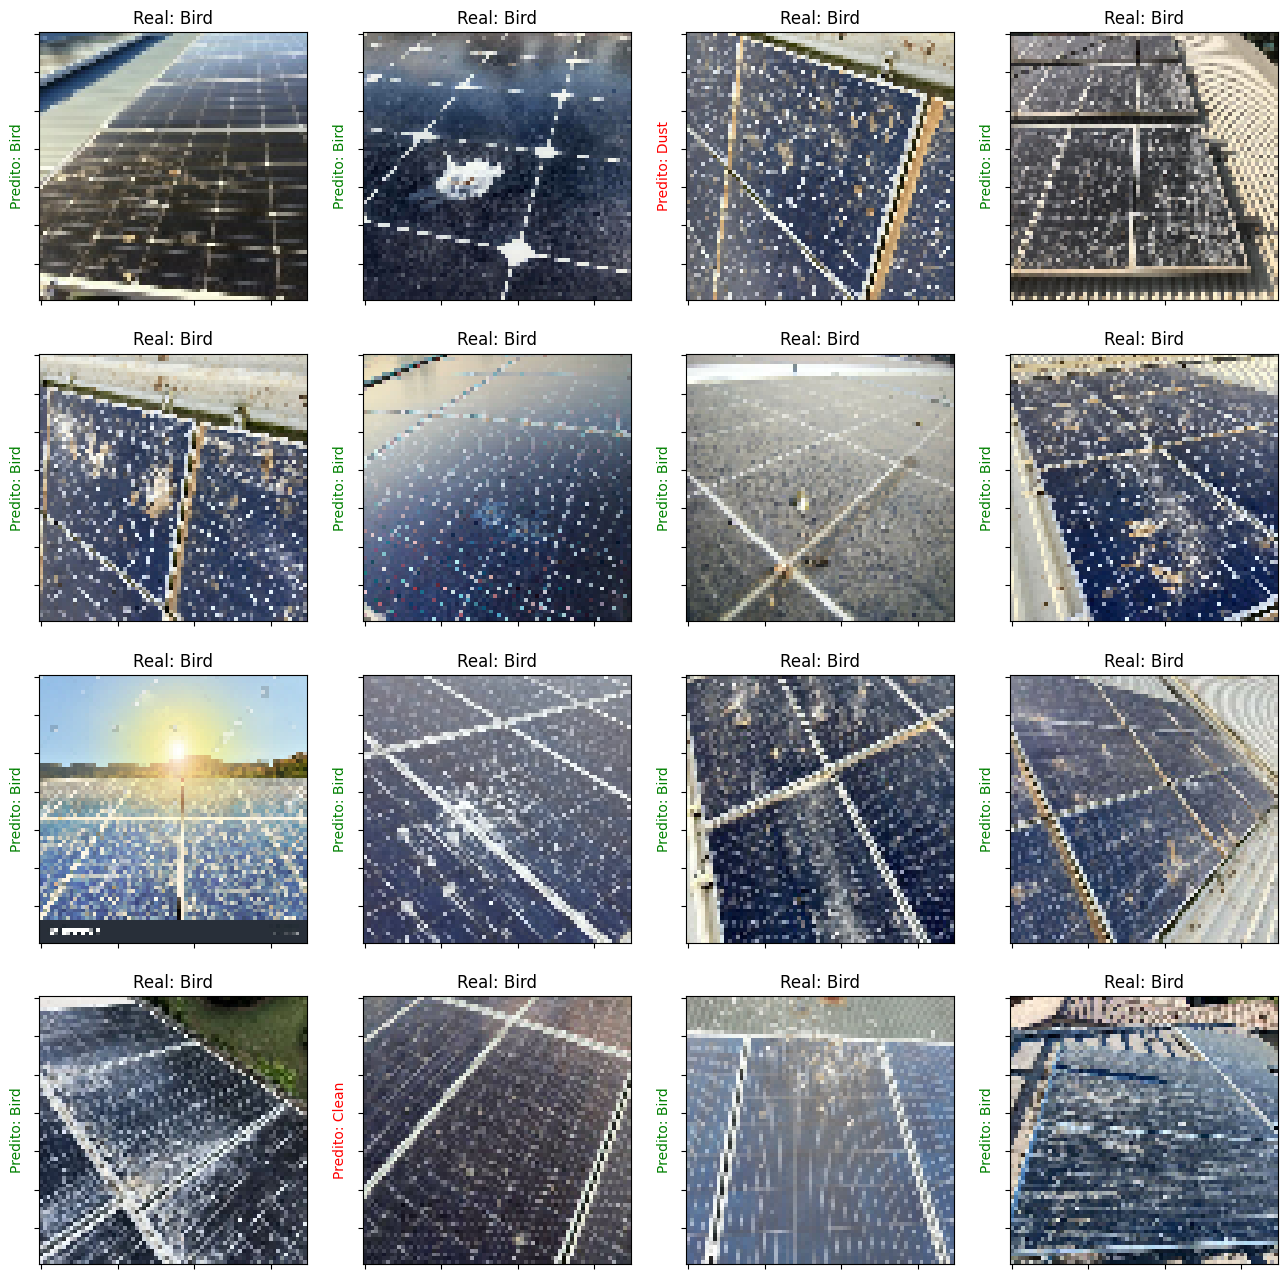

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Considera que as funções 'process_path' e a variável 'dest_test' já estão definidas
# dest_test deve ser: '/content/drive/MyDrive/INSPEÇÃO DE PAINEIS SOLARES/NOVA/TESTE_GERAL'
# class_names e num_classes também devem estar definidas

def load_images_from_dir(directory):
    """
    Carrega imagens e rótulos a partir dos arquivos do diretório.
    Utiliza a função process_path já definida para realizar o pré-processamento.
    Retorna as imagens e os rótulos (como inteiros).
    """
    image_paths = sorted(glob.glob(os.path.join(directory, '*')))
    images = []
    labels = []
    for path in image_paths:
        # process_path retorna (image, label) onde label é one-hot
        image, label = process_path(path)
        images.append(image.numpy())
        # Converte o vetor one-hot para o índice inteiro
        labels.append(int(tf.argmax(label).numpy()))
    return np.array(images), np.array(labels)

# Diretório do conjunto de teste
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'

# Carregar imagens e rótulos do conjunto de teste
images_test, labels_test = load_images_from_dir(test_dir)

# Converter rótulos para one-hot encoding
labels_test_one_hot = to_categorical(labels_test, num_classes=num_classes)

# Avaliar o modelo no conjunto de teste
test_loss, test_accuracy = model.evaluate(images_test, labels_test_one_hot)
print(f"Perda no conjunto de teste: {test_loss:.4f}")
print(f"Acurácia no conjunto de teste: {test_accuracy:.4f}")

# Exibir as imagens e as previsões
plt.figure(figsize=(16, 16))
for i in range(min(16, len(images_test))):  # Exibe até 16 imagens
    ax = plt.subplot(4, 4, i + 1)

    # Desnormalizar a imagem para [0, 255] para exibição
    img_to_show = (images_test[i] * 255).astype("uint8")
    plt.imshow(img_to_show)

    # Obter a predição para a imagem atual
    predictions = model.predict(tf.expand_dims(images_test[i], 0), verbose=0)
    score = tf.nn.softmax(predictions[0])
    predicted_class = np.argmax(score)
    actual_class = labels_test[i]

    # Definir o título e a cor do rótulo com base na acurácia da predição
    plt.title(f"Real: {class_names[actual_class]}")
    if actual_class == predicted_class:
        plt.ylabel(f"Predito: {class_names[predicted_class]}", color='green')
    else:
        plt.ylabel(f"Predito: {class_names[predicted_class]}", color='red')

    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])

plt.show()


# SEGUNDA PARTE

TREINO COM 850 IMAGENS SINTÉTICAS E VALIDACAO COM 150 IMAGENS REAIS DE CADA CLASSE, QUE SÃO AS MESMAS USADAS NA PRIMEIRA PARTE:

output_train_valid = '/content/drive/MyDrive/INSPEÇÃO DE PAINEIS SOLARES/NOVA/TREINO'

RENOMEANDO:

In [ ]:
import os

# Caminho da pasta com as imagens
folder_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/coco_passaro/coco_passaro'

# Renomeia os arquivos
for filename in os.listdir(folder_path):
    if filename.endswith('.png') and not filename.startswith('CP_'):
        old_path = os.path.join(folder_path, filename)
        new_filename = 'CP_' + filename
        new_path = os.path.join(folder_path, new_filename)
        os.rename(old_path, new_path)

print("Arquivos renomeados com sucesso.")


Arquivos renomeados com sucesso.


In [ ]:
import os

# Caminho da nova pasta
folder_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/no_defects/first_dataset'

# Renomeia os arquivos com prefixo "C_"
for filename in os.listdir(folder_path):
    if filename.endswith('.png') and not filename.startswith('C_'):
        old_path = os.path.join(folder_path, filename)
        new_filename = 'C_' + filename
        new_path = os.path.join(folder_path, new_filename)
        os.rename(old_path, new_path)

print("Arquivos renomeados com prefixo 'C_' com sucesso.")


Arquivos renomeados com prefixo 'C_' com sucesso.


In [ ]:
import os

# Caminho da pasta com as imagens
folder_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/sujeira/sujeira'

# Adiciona o prefixo "D_" aos arquivos .png que ainda não têm esse prefixo
for filename in os.listdir(folder_path):
    if filename.endswith('.png') and not filename.startswith('D_'):
        old_path = os.path.join(folder_path, filename)
        new_filename = 'D_' + filename
        new_path = os.path.join(folder_path, new_filename)
        os.rename(old_path, new_path)

print("Arquivos renomeados com prefixo 'D_' com sucesso.")


Arquivos renomeados com prefixo 'D_' com sucesso.


In [ ]:
import os

folder_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID/Bird'

# Conta quantos arquivos existem na pasta
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

print(f"Total de arquivos na pasta 'Bird': {file_count}")


Total de arquivos na pasta 'Bird': 150


In [ ]:
import os

# Lista de pastas a verificar
folders = {
    "sujeira": '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/sujeira/sujeira',
    "first_dataset": '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/no_defects/first_dataset',
    "coco_passaro": '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/coco_passaro/coco_passaro'
}

# Contar arquivos de imagem em cada pasta
for name, path in folders.items():
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{name}: {count} imagens")


sujeira: 1000 imagens
first_dataset: 1000 imagens
coco_passaro: 1000 imagens


In [ ]:
import os
import shutil

# Caminhos
src_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID/Bird'
dst_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Bird'
os.makedirs(dst_dir, exist_ok=True)

# Renomear e copiar imagens
count = 0
for filename in os.listdir(src_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        old_path = os.path.join(src_dir, filename)
        new_filename = f'CP_{filename}'
        new_path = os.path.join(dst_dir, new_filename)
        shutil.copy2(old_path, new_path)
        count += 1

print(f"Total de imagens copiadas e renomeadas: {count}")


Total de imagens copiadas e renomeadas: 150


In [ ]:
import os
import shutil

# Caminhos
src_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID/Clean'
dst_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Clean'
os.makedirs(dst_dir, exist_ok=True)

# Renomear e copiar imagens
count = 0
for filename in os.listdir(src_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        old_path = os.path.join(src_dir, filename)
        new_filename = f'C_{filename}'
        new_path = os.path.join(dst_dir, new_filename)
        shutil.copy2(old_path, new_path)
        count += 1

print(f"Total de imagens copiadas e renomeadas: {count}")


Total de imagens copiadas e renomeadas: 150


In [ ]:
import os
import shutil

# Caminhos de origem e destino
src_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - Kaggle/TREINO_VALID/Dust'
dst_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Dust'
os.makedirs(dst_dir, exist_ok=True)

# Renomear e copiar os arquivos
count = 0
for filename in os.listdir(src_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        new_filename = f"D_{filename}"
        src_path = os.path.join(src_dir, filename)
        dst_path = os.path.join(dst_dir, new_filename)
        shutil.copy2(src_path, dst_path)
        count += 1

print(f"Total de arquivos renomeados e copiados: {count}")


Total de arquivos renomeados e copiados: 150


EM: output_train_valid = '/content/drive/MyDrive/INSPEÇÃO DE PAINEIS SOLARES/NOVA/TREINO'

Bird: TREINO/VALID = 150 arquivos

Clean: TREINO/VALID = 150 arquivos

Dust: TREINO/VALID = 150 arquivos

1. MONTAR UM CONJUNTO DE TREINO_GERAL COM 850 IMAGENS SINTETICAS + 150 REAIS = 1000 IMAGENS PARA CADA CLASSE.

2. DIVIDIR EM PARA_TREINO E PARA_VALID

3. REPETIR Passo 04: Treinar o Modelo

In [ ]:
import os
import shutil
import random

# Diretórios
bird_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Bird'
synth_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/coco_passaro/coco_passaro'
output_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_GERAL'
os.makedirs(output_dir, exist_ok=True)

# Copiar todas as imagens da pasta Bird
count = 0
for filename in os.listdir(bird_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        src_path = os.path.join(bird_dir, filename)
        dst_path = os.path.join(output_dir, filename)
        shutil.copy2(src_path, dst_path)
        count += 1

# Selecionar 850 imagens da pasta sintética
synth_images = [f for f in os.listdir(synth_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_synth = random.sample(synth_images, 850)

# Copiar as 850 imagens com prefixo 'CP_'
for filename in selected_synth:
    src_path = os.path.join(synth_dir, filename)
    new_name = 'CP_' + filename if not filename.startswith('CP_') else filename
    dst_path = os.path.join(output_dir, new_name)
    shutil.copy2(src_path, dst_path)
    count += 1

print(f"Total de imagens copiadas para o destino: {count}")


Total de imagens copiadas para o destino: 1000


In [ ]:
import os
import shutil
import random

# Diretórios de origem e destino
clean_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Clean'
synth_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/no_defects/first_dataset'
output_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_GERAL'

# Criar diretório de destino, se não existir
os.makedirs(output_dir, exist_ok=True)

# Inicializar contador
count = 0

# Copiar todas as imagens da pasta Clean
for filename in os.listdir(clean_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        src = os.path.join(clean_dir, filename)
        dst = os.path.join(output_dir, filename)
        shutil.copy2(src, dst)
        count += 1

# Selecionar 850 imagens aleatórias do dataset sintético
synth_images = [f for f in os.listdir(synth_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_synth = random.sample(synth_images, 850)

# Copiar imagens sintéticas com prefixo 'C_'
for filename in selected_synth:
    src = os.path.join(synth_dir, filename)
    new_name = 'C_' + filename if not filename.startswith('C_') else filename
    dst = os.path.join(output_dir, new_name)
    shutil.copy2(src, dst)
    count += 1

# Mostrar quantidade final
print(f"Total de imagens copiadas para o destino: {count}")


Total de imagens copiadas para o destino: 1000


In [ ]:
import os
import shutil
import random

# Diretórios
real_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_VALID/Dust'
synthetic_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000/sujeira/sujeira'
output_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_GERAL'

# Criar o diretório de destino se não existir
os.makedirs(output_dir, exist_ok=True)

# Inicializar contador
total_count = 0

# Copiar todas as imagens reais (Dust)
for filename in os.listdir(real_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        src = os.path.join(real_dir, filename)
        dst = os.path.join(output_dir, filename)
        shutil.copy2(src, dst)
        total_count += 1

# Selecionar 850 imagens sintéticas aleatórias
synthetic_images = [f for f in os.listdir(synthetic_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_synthetic = random.sample(synthetic_images, 850)

# Copiar imagens sintéticas com prefixo 'D_'
for filename in selected_synthetic:
    src = os.path.join(synthetic_dir, filename)
    new_name = 'D_' + filename if not filename.startswith('D_') else filename
    dst = os.path.join(output_dir, new_name)
    shutil.copy2(src, dst)
    total_count += 1

# Imprimir total
print(f"Total de imagens copiadas para o destino: {total_count}")


Total de imagens copiadas para o destino: 1000


In [ ]:
import os

# Caminho do diretório de interesse
folder_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_GERAL'

# Inicializar contadores
total_files = 0
count_cp = 0
count_d = 0
count_c = 0

# Contar os arquivos e identificar pelas iniciais
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # pode ajustar se houver outros formatos
        total_files += 1
        if filename.startswith("CP_"):
            count_cp += 1
        elif filename.startswith("D_"):
            count_d += 1
        elif filename.startswith("C_"):
            count_c += 1

# Exibir resultados
print(f"Total de arquivos: {total_files}")
print(f"Classe CP_ (Pássaro): {count_cp}")
print(f"Classe D_ (Sujeira): {count_d}")
print(f"Classe C_ (Limpo): {count_c}")


Total de arquivos: 3000
Classe CP_ (Pássaro): 1000
Classe D_ (Sujeira): 1000
Classe C_ (Limpo): 1000


In [ ]:
import os
import shutil
import random

# Caminho da pasta com todos os arquivos
base_folder = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/TREINO_GERAL'

# Destinos
train_base = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TREINO'
valid_base = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_VALID'

# Prefixos das classes
prefixes = ['C_', 'D_', 'CP_']

# Criar diretórios de destino (sem subpastas)
os.makedirs(train_base, exist_ok=True)
os.makedirs(valid_base, exist_ok=True)

# Separar e copiar os arquivos
for prefix in prefixes:
    # Filtrar arquivos com o prefixo
    class_files = [f for f in os.listdir(base_folder) if f.startswith(prefix)]
    random.shuffle(class_files)

    # Dividir em 80% treino, 20% validação
    split_index = int(0.8 * len(class_files))
    train_files = class_files[:split_index]
    valid_files = class_files[split_index:]

    # Copiar arquivos para treino
    for f in train_files:
        src_path = os.path.join(base_folder, f)
        dst_path = os.path.join(train_base, f)
        shutil.copy2(src_path, dst_path)

    # Copiar arquivos para validação
    for f in valid_files:
        src_path = os.path.join(base_folder, f)
        dst_path = os.path.join(valid_base, f)
        shutil.copy2(src_path, dst_path)

    print(f"{prefix}: {len(train_files)} arquivos copiados para treino, {len(valid_files)} para validação")

print(" Separação e cópia concluídas!")


C_: 800 arquivos copiados para treino, 200 para validação
D_: 800 arquivos copiados para treino, 200 para validação
CP_: 800 arquivos copiados para treino, 200 para validação
 Separação e cópia concluídas!


In [ ]:
import os
import shutil

# Caminho da pasta de origem
source_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1/PARA_TESTE'

# Caminho da pasta de destino
target_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TESTE'

# Garante que o diretório de destino existe
os.makedirs(target_dir, exist_ok=True)

# Mapeamento das classes para prefixos
prefix_map = {
    'Bird': 'CP_',
    'Clean': 'C_',
    'Dust': 'D_'
}

# Processa e copia os arquivos
for filename in os.listdir(source_dir):
    for class_name, prefix in prefix_map.items():
        if filename.startswith(class_name):
            ext = os.path.splitext(filename)[1]  # ex: .jpg
            new_name = prefix + filename.replace(class_name, '').strip()
            src = os.path.join(source_dir, filename)
            dst = os.path.join(target_dir, new_name)
            shutil.copy2(src, dst)
            print(f'Copiado e renomeado: {filename} → {new_name}')
            break

print(" Arquivos copiados e renomeados para PARTE 2.")


Copiado e renomeado: Bird (176).jpg → CP_(176).jpg
Copiado e renomeado: Bird (189).jpg → CP_(189).jpg
Copiado e renomeado: Bird (102).jpg → CP_(102).jpg
Copiado e renomeado: Bird (22).jpg → CP_(22).jpg
Copiado e renomeado: Bird (88).jpg → CP_(88).jpg
Copiado e renomeado: Bird (138).JPG → CP_(138).JPG
Copiado e renomeado: Bird (145).jpg → CP_(145).jpg
Copiado e renomeado: Bird (1).jpeg → CP_(1).jpeg
Copiado e renomeado: Bird (182).jpg → CP_(182).jpg
Copiado e renomeado: Bird (186).jpg → CP_(186).jpg
Copiado e renomeado: Bird (41).jpg → CP_(41).jpg
Copiado e renomeado: Bird (103).jpg → CP_(103).jpg
Copiado e renomeado: Bird (180).jpg → CP_(180).jpg
Copiado e renomeado: Bird (143).jpg → CP_(143).jpg
Copiado e renomeado: Bird (101).jpg → CP_(101).jpg
Copiado e renomeado: Bird (94).jpg → CP_(94).jpg
Copiado e renomeado: Bird (4).jpg → CP_(4).jpg
Copiado e renomeado: Bird (104).jpg → CP_(104).jpg
Copiado e renomeado: Bird (67).jpg → CP_(67).jpg
Copiado e renomeado: Bird (76).jpg → CP_(76).jp

In [ ]:
import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Diretórios onde as imagens estão armazenadas (imagens diretamente na pasta)
dest_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TREINO'
dest_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_VALID'
dest_test  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TESTE'

# Parâmetros
image_size = (70, 70)
batch_size = 32

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo da imagem a partir do prefixo do nome do arquivo.
    Exemplo: "C_abc.jpg" → Clean, "D_xyz.png" → Dust, "CP_12.jpg" → Bird
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Criação dos datasets
train_dataset = create_dataset(dest_train).repeat()
valid_dataset = create_dataset(dest_valid).repeat()
test_dataset  = create_dataset(dest_test)

def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

n_train = count_images(dest_train)
n_valid = count_images(dest_valid)

steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print("Total de imagens de treino:", n_train)
print("Total de imagens de validação:", n_valid)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Classes:", class_names)

# Construção do modelo
model = Sequential()

# Bloco 1
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01), input_shape=(70, 70, 3)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 4
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Densas finais
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compilar modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00004),
    metrics=['accuracy']
)

model.summary()

# Treinamento
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_dataset,
    validation_steps=validation_steps,
    epochs=50
)

# Gráficos de treinamento
def plot_training_history(history):
    acc_key = 'accuracy'
    val_acc_key = 'val_accuracy'
    epochs = list(range(1, len(history.history['loss']) + 1))

    fig_acc = go.Figure()
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[acc_key], mode='lines+markers', name='Acurácia Treino'))
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[val_acc_key], mode='lines+markers', name='Acurácia Validação'))
    fig_acc.update_layout(title='Evolução da Acurácia por Época', xaxis_title='Época', yaxis_title='Acurácia', template='plotly_dark')

    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['loss'], mode='lines+markers', name='Perda Treino'))
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'], mode='lines+markers', name='Perda Validação'))
    fig_loss.update_layout(title='Evolução da Perda por Época', xaxis_title='Época', yaxis_title='Perda', template='plotly_dark')

    fig_acc.show()
    fig_loss.show()

plot_training_history(history)

# Salvar modelo
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/modelo_treinado_PARTE_2.h5'
model.save(model_save_path)
print(f" Modelo salvo em: {model_save_path}")


Total de imagens de treino: 2400
Total de imagens de validação: 600
Steps per epoch: 75
Validation steps: 18
Classes: ['Bird', 'Clean', 'Dust']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 775s 3s/step - accuracy: 0.6538 - loss: 26.3005 - val_accuracy: 0.3368 - val_loss: 26.1849
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7553 - loss: 25.6315 - val_accuracy: 0.3403 - val_loss: 26.2258
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8002 - loss: 25.2905 - val_accuracy: 0.3368 - val_loss: 26.9272
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8466 - loss: 24.8742 - val_accuracy: 0.3264 - val_loss: 28.7520
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8934 - loss: 24.5375 - val_accuracy: 0.3333 - val_loss: 28.2643
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9032 - loss: 24.1869 - val_accuracy: 0.3385 - val_loss: 30.0609
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9127 - loss: 23.8381 - val_accuracy: 0.3368 - val_loss: 31.3015
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9510 - loss: 23.4373 - v

ENGLISH

In [ ]:
 import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam

# Diretórios onde as imagens estão armazenadas
dest_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TREINO'
dest_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_VALID'
dest_test  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TESTE'

# Parâmetros
image_size = (70, 70)
batch_size = 32
epochs = 100
learning_rate = 4e-5

# Definição das classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Tabela para mapear nome da classe a índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    idx = table.lookup(class_name)
    return tf.one_hot(idx, depth=num_classes)

def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

def create_dataset(directory, repeat=False):
    pattern = os.path.join(directory, '*')
    ds = tf.data.Dataset.list_files(pattern, shuffle=False)
    ds = ds.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000)
    ds = ds.batch(batch_size)
    if repeat:
        ds = ds.repeat()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

# Criando os datasets
n_train = count_images(dest_train)
n_valid = count_images(dest_valid)

train_ds = create_dataset(dest_train, repeat=True)
valid_ds = create_dataset(dest_valid, repeat=True)
test_ds  = create_dataset(dest_test, repeat=False)

steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print(f"Train images: {n_train}, Validation images: {n_valid}")
print(f"Steps per epoch: {steps_per_epoch}, Validation steps: {validation_steps}")
print(f"Classes: {class_names}")

# Construção do modelo
model = Sequential([
    # Block 1
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01), input_shape=(70,70,3)),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    # Block 2
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    # Block 3
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    # Block 4
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)),
    BatchNormalization(),

    # Dense head
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax'),
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)

model.summary()

# Treinamento
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_ds,
    validation_steps=validation_steps,
    epochs=epochs
)

# Função para plotar a evolução do treinamento em inglês
def plot_training_history(history):
    # detect metric
    if 'accuracy' in history.history:
        metric = 'accuracy'
    else:
        metric = list(history.history.keys())[1]
    val_metric = f'val_{metric}'

    epochs_range = list(range(1, len(history.history['loss'])+1))

    # Metric plot
    fig_metric = go.Figure()
    fig_metric.add_trace(go.Scatter(
        x=epochs_range,
        y=history.history[metric],
        mode='lines+markers',
        name=f'Train {metric.title()}'
    ))
    fig_metric.add_trace(go.Scatter(
        x=epochs_range,
        y=history.history[val_metric],
        mode='lines+markers',
        name=f'Validation {metric.title()}'
    ))
    fig_metric.update_layout(
        title=f'{metric.title()} Over Epochs',
        xaxis_title='Epoch',
        yaxis_title=metric.title(),
        template='plotly_white'
    )

    # Loss plot
    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(
        x=epochs_range,
        y=history.history['loss'],
        mode='lines+markers',
        name='Train Loss'
    ))
    fig_loss.add_trace(go.Scatter(
        x=epochs_range,
        y=history.history['val_loss'],
        mode='lines+markers',
        name='Validation Loss'
    ))
    fig_loss.update_layout(
        title='Loss Over Epochs',
        xaxis_title='Epoch',
        yaxis_title='Loss',
        template='plotly_white'
    )

    fig_metric.show()
    fig_loss.show()

# Plotar métricas
plot_training_history(history)

# Salvar modelo
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/modelo_treinado_PARTE_2.h5'
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")


Train images: 2400, Validation images: 600
Steps per epoch: 75, Validation steps: 18
Classes: ['Bird', 'Clean', 'Dust']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 763s 3s/step - accuracy: 0.6829 - loss: 26.2476 - val_accuracy: 0.3333 - val_loss: 26.2626
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.7709 - loss: 25.6519 - val_accuracy: 0.3368 - val_loss: 26.5345
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.7960 - loss: 25.2719 - val_accuracy: 0.3351 - val_loss: 27.2204
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8298 - loss: 24.9630 - val_accuracy: 0.3299 - val_loss: 28.3800
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.8467 - loss: 24.6201 - val_accuracy: 0.3368 - val_loss: 29.7193
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.8883 - loss: 24.1980 - val_accuracy: 0.3368 - val_loss: 29.5149
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.9284 - loss: 23.8342 - val_accuracy: 0.3420 - val_loss: 28.9917
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.9483 - loss: 23.4515 - v

TESTANDO

In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import plotly.graph_objects as go

# Caminho do conjunto de teste
target_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/PARA_TESTE'

# Parâmetros
image_size = (70, 70)
batch_size = 32
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Tabela de lookup
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

# Função para extrair o rótulo a partir do prefixo do nome do arquivo
def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

# Pré-processamento da imagem
def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

# Criar dataset de teste
def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Carregar dataset de teste
test_dataset = create_dataset(target_dir)

# Carregar modelo treinado
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 2/modelo_treinado_PARTE_2.h5'
model = tf.keras.models.load_model(model_path)

# Obter predições
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Nome das classes
class_labels = ["Bird", "Clean", "Dust"]

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusão
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualização com Plotly e anotações nas células
z = conf_matrix
x = class_labels
y = class_labels

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Blues',
    showscale=True,
    hovertemplate='Verdadeiro: %{y}<br>Predito: %{x}<br>Qtd: %{z}<extra></extra>'
))

annotations = []
for i in range(len(y)):
    for j in range(len(x)):
        annotations.append(
            dict(
                text=str(z[i][j]),
                x=x[j],
                y=y[i],
                xref='x1',
                yref='y1',
                showarrow=False,
                font=dict(
                    color='black' if z[i][j] < np.max(z)/2 else 'white',
                    size=14
                )
            )
        )

fig_cm.update_layout(
    title='Confusion Matrix – Test Set',
    xaxis=dict(title='Predicted Label'),
    yaxis=dict(title='True Label', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig_cm.show()

# TERCEIRA PARTE

In [ ]:
import os
import shutil
import random

# Semente para reprodutibilidade
random.seed(42)

# Caminho base dos conjuntos originais
base_input = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 1000"

# Cada tupla é (pasta_pai, pasta_categoria)
datasets = [
    ("coco_passaro", "coco_passaro"),
    ("no_defects",  "first_dataset"),
    ("sujeira",     "sujeira"),
]

# Caminho base de saída
output_base = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3"

# Proporções de divisão
splits = {
    "PARA_TREINO": 0.8,
    "PARA_VALID":  0.1,
    "PARA_TESTE":  0.1,
}

# Garante que as pastas de saída existam
for split in splits:
    os.makedirs(os.path.join(output_base, split), exist_ok=True)

# Processa cada categoria
for pasta_pai, pasta_cat in datasets:
    input_dir = os.path.join(base_input, pasta_pai, pasta_cat)
    if not os.path.isdir(input_dir):
        print(f"[AVISO] Diretório não encontrado: {input_dir}")
        continue

    # Lista todos os arquivos (imagens) na pasta
    arquivos = [f for f in os.listdir(input_dir)
                if os.path.isfile(os.path.join(input_dir, f))]
    random.shuffle(arquivos)

    n_total = len(arquivos)
    n_train = int(n_total * splits["PARA_TREINO"])
    n_valid = int(n_total * splits["PARA_VALID"])
    # o restante vai para teste
    # n_test = n_total - n_train - n_valid

    # Distribui os arquivos
    distribuicao = {
        "PARA_TREINO": arquivos[:n_train],
        "PARA_VALID":  arquivos[n_train:n_train + n_valid],
        "PARA_TESTE":  arquivos[n_train + n_valid:],
    }

    # Copia para as pastas de saída
    for split_name, lista_files in distribuicao.items():
        dest_dir = os.path.join(output_base, split_name, pasta_cat)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in lista_files:
            src = os.path.join(input_dir, fname)
            dst = os.path.join(dest_dir,   fname)
            shutil.copy2(src, dst)

print("Divisão concluída: treino (80%), validação (10%) e teste (10%).")


Divisão concluída: treino (80%), validação (10%) e teste (10%).


In [ ]:
import os
import shutil

# Diretório raiz que contém subpastas com arquivos de imagem
base_dir = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TESTE"

# Percorre toda a árvore de diretórios de forma bottom‑up
for root, dirs, files in os.walk(base_dir, topdown=False):
    # pula a própria pasta base para não mover arquivos que já estão nela
    if root == base_dir:
        continue

    for filename in files:
        src_path = os.path.join(root, filename)
        dst_path = os.path.join(base_dir, filename)

        # Se já existir um arquivo com esse nome na pasta base, renomeia para evitar colisão
        if os.path.exists(dst_path):
            name, ext = os.path.splitext(filename)
            i = 1
            # incrementa sufixo "_1", "_2", ... até achar um nome livre
            while os.path.exists(dst_path):
                new_name = f"{name}_{i}{ext}"
                dst_path = os.path.join(base_dir, new_name)
                i += 1

        # move o arquivo para a pasta base
        shutil.move(src_path, dst_path)

    # após mover todos os arquivos, remove a subpasta (que agora está vazia)
    try:
        os.rmdir(root)
    except OSError:
        # se a pasta não estiver vazia (por algum motivo), ignora
        pass

print("Arquivos centralizados em PARA_TESTE e subpastas removidas.")

Arquivos centralizados em PARA_TESTE e subpastas removidas.


In [ ]:
import os
import shutil

# Diretório raiz que contém subpastas com arquivos de imagem
base_dir = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TREINO"

# Percorre toda a árvore de diretórios de forma bottom‑up
for root, dirs, files in os.walk(base_dir, topdown=False):
    # pula a própria pasta base para não mover arquivos que já estão nela
    if root == base_dir:
        continue

    for filename in files:
        src_path = os.path.join(root, filename)
        dst_path = os.path.join(base_dir, filename)

        # Se já existir um arquivo com esse nome na pasta base, renomeia para evitar colisão
        if os.path.exists(dst_path):
            name, ext = os.path.splitext(filename)
            i = 1
            # incrementa sufixo "_1", "_2", ... até achar um nome livre
            while os.path.exists(dst_path):
                new_name = f"{name}_{i}{ext}"
                dst_path = os.path.join(base_dir, new_name)
                i += 1

        # move o arquivo para a pasta base
        shutil.move(src_path, dst_path)

    # após mover todos os arquivos, remove a subpasta (que agora está vazia)
    try:
        os.rmdir(root)
    except OSError:
        # se a pasta não estiver vazia (por algum motivo), ignora
        pass

print("Arquivos centralizados em PARA_TREINO e subpastas removidas.")

Arquivos centralizados em PARA_TESTE e subpastas removidas.


In [ ]:
import os
import shutil

# Diretório raiz que contém subpastas com arquivos de imagem
base_dir = "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_VALID"

# Percorre toda a árvore de diretórios de forma bottom‑up
for root, dirs, files in os.walk(base_dir, topdown=False):
    # pula a própria pasta base para não mover arquivos que já estão nela
    if root == base_dir:
        continue

    for filename in files:
        src_path = os.path.join(root, filename)
        dst_path = os.path.join(base_dir, filename)

        # Se já existir um arquivo com esse nome na pasta base, renomeia para evitar colisão
        if os.path.exists(dst_path):
            name, ext = os.path.splitext(filename)
            i = 1
            # incrementa sufixo "_1", "_2", ... até achar um nome livre
            while os.path.exists(dst_path):
                new_name = f"{name}_{i}{ext}"
                dst_path = os.path.join(base_dir, new_name)
                i += 1

        # move o arquivo para a pasta base
        shutil.move(src_path, dst_path)

    # após mover todos os arquivos, remove a subpasta (que agora está vazia)
    try:
        os.rmdir(root)
    except OSError:
        # se a pasta não estiver vazia (por algum motivo), ignora
        pass

print("Arquivos centralizados em PARA_VALID e subpastas removidas.")

Arquivos centralizados em PARA_TESTE e subpastas removidas.


In [ ]:
import os

# Diretórios a serem contados
dirs = {
    "VALID": "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_VALID",
    "TREINO": "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TREINO",
    "TESTE": "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TESTE",
}

def count_files(base_dir, recursive=True):
    """
    Conta todos os arquivos dentro de base_dir.
    Se recursive for True, conta em subpastas também.
    """
    count = 0
    if recursive:
        for root, _, files in os.walk(base_dir):
            count += len(files)
    else:
        count = len([f for f in os.listdir(base_dir)
                     if os.path.isfile(os.path.join(base_dir, f))])
    return count

# Executa a contagem para cada pasta
for name, path in dirs.items():
    total = count_files(path, recursive=True)
    print(f"{name}: {total} arquivos")


VALID: 300 arquivos
TREINO: 2400 arquivos
TESTE: 300 arquivos


In [ ]:
import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Diretórios onde as imagens estão armazenadas (imagens diretamente na pasta)
dest_train = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TREINO'
dest_valid = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_VALID'
dest_test  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TESTE'



# Parâmetros
image_size = (70, 70)
batch_size = 32

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo da imagem a partir do prefixo do nome do arquivo.
    Exemplo: "C_abc.jpg" → Clean, "D_xyz.png" → Dust, "CP_12.jpg" → Bird
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Criação dos datasets
train_dataset = create_dataset(dest_train).repeat()
valid_dataset = create_dataset(dest_valid).repeat()
test_dataset  = create_dataset(dest_test)

def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

n_train = count_images(dest_train)
n_valid = count_images(dest_valid)

steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print("Total de imagens de treino:", n_train)
print("Total de imagens de validação:", n_valid)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Classes:", class_names)

# Construção do modelo
model = Sequential()

# Bloco 1
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01), input_shape=(70, 70, 3)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 4
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Densas finais
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compilar modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00004),
    metrics=['accuracy']
)

model.summary()

# Treinamento
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_dataset,
    validation_steps=validation_steps,
    epochs=50
)

# Gráficos de treinamento
def plot_training_history(history):
    acc_key = 'accuracy'
    val_acc_key = 'val_accuracy'
    epochs = list(range(1, len(history.history['loss']) + 1))

    fig_acc = go.Figure()
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[acc_key], mode='lines+markers', name='Acurácia Treino'))
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[val_acc_key], mode='lines+markers', name='Acurácia Validação'))
    fig_acc.update_layout(title='Evolução da Acurácia por Época', xaxis_title='Época', yaxis_title='Acurácia', template='plotly_dark')

    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['loss'], mode='lines+markers', name='Perda Treino'))
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'], mode='lines+markers', name='Perda Validação'))
    fig_loss.update_layout(title='Evolução da Perda por Época', xaxis_title='Época', yaxis_title='Perda', template='plotly_dark')

    fig_acc.show()
    fig_loss.show()

plot_training_history(history)

# Salvar modelo
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/modelo_treinado_PARTE_3.h5'
model.save(model_save_path)
print(f" Modelo salvo em: {model_save_path}")


Total de imagens de treino: 2400
Total de imagens de validação: 300
Steps per epoch: 75
Validation steps: 9
Classes: ['Bird', 'Clean', 'Dust']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6983 - loss: 26.1370 - val_accuracy: 0.3403 - val_loss: 26.1467
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8237 - loss: 25.4322 - val_accuracy: 0.3333 - val_loss: 25.9465
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8940 - loss: 24.9957 - val_accuracy: 0.3333 - val_loss: 25.6828
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9309 - loss: 24.6262 - val_accuracy: 0.3403 - val_loss: 25.3364
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9234 - loss: 24.3296 - val_accuracy: 0.3299 - val_loss: 25.6769
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9417 - loss: 23.9495 - val_accuracy: 0.5694 - val_loss: 25.4948
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9603 - loss: 23.5284 - val_accuracy: 0.3264 - val_loss: 27.2559
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.9900 - loss: 23.1055 - val_accur

 Modelo salvo em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/modelo_treinado_PARTE_3.h5


In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import plotly.graph_objects as go

# Caminho do conjunto de teste
target_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/PARA_TESTE'

# Parâmetros
image_size = (70, 70)
batch_size = 32
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Tabela de lookup
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

# Função para extrair o rótulo a partir do prefixo do nome do arquivo
def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

# Pré-processamento da imagem
def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

# Criar dataset de teste
def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Carregar dataset de teste
test_dataset = create_dataset(target_dir)

# Carregar modelo treinado
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 3/modelo_treinado_PARTE_3.h5'
model = tf.keras.models.load_model(model_path)

# Obter predições
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Nome das classes
class_labels = ["Bird", "Clean", "Dust"]

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusão
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualização com Plotly e anotações nas células
z = conf_matrix
x = class_labels
y = class_labels

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Blues',
    showscale=True,
    hovertemplate='Verdadeiro: %{y}<br>Predito: %{x}<br>Qtd: %{z}<extra></extra>'
))

annotations = []
for i in range(len(y)):
    for j in range(len(x)):
        annotations.append(
            dict(
                text=str(z[i][j]),
                x=x[j],
                y=y[i],
                xref='x1',
                yref='y1',
                showarrow=False,
                font=dict(
                    color='black' if z[i][j] < np.max(z)/2 else 'white',
                    size=14
                )
            )
        )

fig.update_layout(
    title='Matriz de Confusão - Teste',
    xaxis=dict(title='Predito'),
    yaxis=dict(title='Verdadeiro', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

        Bird       1.00      0.85      0.92       100
       Clean       1.00      0.91      0.95       100
        Dust       0.81      1.00      0.89       100

    accuracy                           0.92       300
   macro avg       0.94      0.92      0.92       300
weighted avg       0.94      0.92      0.92       300



# QUARTA PARTE

In [ ]:
import os

# Função para renomear arquivos adicionando prefixo
def rename_files_in_directory(directory_path, prefix):
    # Lista todos os arquivos na pasta
    files = os.listdir(directory_path)

    # Renomeia cada arquivo com o prefixo
    for file in files:
        file_path = os.path.join(directory_path, file)

        # Verifica se é um arquivo (e não uma pasta)
        if os.path.isfile(file_path):
            new_name = prefix + file
            new_file_path = os.path.join(directory_path, new_name)
            os.rename(file_path, new_file_path)
            print(f'Renamed: {file} to {new_name}')

# Diretórios das pastas
bird_drop_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Bird-drop'
clean_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Clean'
dusty_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Dusty'

# Renomear arquivos nas pastas
rename_files_in_directory(bird_drop_dir, 'CP_')
rename_files_in_directory(clean_dir, 'C_')
rename_files_in_directory(dusty_dir, 'D_')


Renamed: Bird (114).jpg to CP_Bird (114).jpg
Renamed: Bird (107).jpg to CP_Bird (107).jpg
Renamed: Bird (110).jpg to CP_Bird (110).jpg
Renamed: Bird (111).jpg to CP_Bird (111).jpg
Renamed: Bird (100).jpg to CP_Bird (100).jpg
Renamed: Bird (1).jpeg to CP_Bird (1).jpeg
Renamed: Bird (11).jpg to CP_Bird (11).jpg
Renamed: Bird (106).jpg to CP_Bird (106).jpg
Renamed: Bird (109).jpg to CP_Bird (109).jpg
Renamed: Bird (112).jpg to CP_Bird (112).jpg
Renamed: Bird (116).jpg to CP_Bird (116).jpg
Renamed: Bird (101).jpg to CP_Bird (101).jpg
Renamed: Bird (115).jpg to CP_Bird (115).jpg
Renamed: Bird (117).jpg to CP_Bird (117).jpg
Renamed: Bird (10).jpg to CP_Bird (10).jpg
Renamed: Bird (119).jpg to CP_Bird (119).jpg
Renamed: Bird (103).jpg to CP_Bird (103).jpg
Renamed: Bird (105).jpg to CP_Bird (105).jpg
Renamed: Bird (108).jpg to CP_Bird (108).jpg
Renamed: Bird (113).jpg to CP_Bird (113).jpg
Renamed: Bird (102).jpg to CP_Bird (102).jpg
Renamed: Bird (118).jpg to CP_Bird (118).jpg
Renamed: Bird (1

In [ ]:
import os
import shutil
import random

# Função para dividir arquivos em treino, validação e teste
def split_data(input_dir, train_dir, valid_dir, test_dir, prefix):
    # Lista os arquivos na pasta
    files = os.listdir(input_dir)

    # Filtra apenas arquivos (não pastas)
    files = [file for file in files if os.path.isfile(os.path.join(input_dir, file))]

    # Embaralha os arquivos para garantir uma divisão aleatória
    random.shuffle(files)

    # Calcula os índices para dividir os arquivos
    total_files = len(files)
    train_size = int(0.8 * total_files)
    valid_size = int(0.1 * total_files)

    # Divide os arquivos em treino, validação e teste
    train_files = files[:train_size]
    valid_files = files[train_size:train_size + valid_size]
    test_files = files[train_size + valid_size:]

    # Função para mover arquivos para o diretório apropriado
    def move_files(file_list, target_dir):
        for file in file_list:
            src = os.path.join(input_dir, file)
            dst = os.path.join(target_dir, prefix + file)
            shutil.move(src, dst)

    # Move os arquivos para os respectivos diretórios
    move_files(train_files, train_dir)
    move_files(valid_files, valid_dir)
    move_files(test_files, test_dir)

    # Imprime a contagem dos arquivos por conjunto e classe
    print(f"Contagem para a classe {prefix}:")
    print(f"Treinamento: {len(train_files)} arquivos")
    print(f"Validação: {len(valid_files)} arquivos")
    print(f"Teste: {len(test_files)} arquivos")
    print('-' * 40)

# Diretórios de entrada e saída
bird_drop_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Bird-drop'
clean_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Clean'
dusty_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/Dusty'

train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_TREINO'
valid_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_VALID'
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_TESTE'

# Criar os diretórios de saída, caso não existam
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Dividir e mover os arquivos para os diretórios de treino, validação e teste
split_data(bird_drop_dir, train_dir, valid_dir, test_dir, 'CP_')
split_data(clean_dir, train_dir, valid_dir, test_dir, 'C_')
split_data(dusty_dir, train_dir, valid_dir, test_dir, 'D_')

# Contagem total de arquivos por diretório
def count_files(directory, prefix):
    files = os.listdir(directory)
    return len([file for file in files if file.startswith(prefix)])

# Imprimir contagem total para cada diretório e classe
print("Contagem total de arquivos por conjunto e classe:")
print(f"Treinamento: CP: {count_files(train_dir, 'CP_')}, C: {count_files(train_dir, 'C_')}, D: {count_files(train_dir, 'D_')}")
print(f"Validação: CP: {count_files(valid_dir, 'CP_')}, C: {count_files(valid_dir, 'C_')}, D: {count_files(valid_dir, 'D_')}")
print(f"Teste: CP: {count_files(test_dir, 'CP_')}, C: {count_files(test_dir, 'C_')}, D: {count_files(test_dir, 'D_')}")


Contagem para a classe CP_:
Treinamento: 153 arquivos
Validação: 19 arquivos
Teste: 20 arquivos
----------------------------------------
Contagem para a classe C_:
Treinamento: 155 arquivos
Validação: 19 arquivos
Teste: 20 arquivos
----------------------------------------
Contagem para a classe D_:
Treinamento: 152 arquivos
Validação: 19 arquivos
Teste: 20 arquivos
----------------------------------------
Contagem total de arquivos por conjunto e classe:
Treinamento: CP: 153, C: 155, D: 152
Validação: CP: 19, C: 19, D: 19
Teste: CP: 20, C: 20, D: 20


In [ ]:
import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Diretórios onde as imagens estão armazenadas (imagens diretamente na pasta)
train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_TREINO'
valid_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_VALID'
test_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_TESTE'

# Parâmetros
image_size = (70, 70)  # Tamanho das imagens para redimensionamento
batch_size = 32

# Definição das classes e número de classes
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# Cria uma tabela de lookup para converter o nome da classe em um índice
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

def get_label_from_filename(file_path):
    """
    Extrai o rótulo da imagem a partir do prefixo do nome do arquivo.
    Exemplo: "C_abc.jpg" → Clean, "D_xyz.png" → Dust, "CP_12.jpg" → Bird
    """
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Criação dos datasets
train_dataset = create_dataset(train_dir).repeat()
valid_dataset = create_dataset(valid_dir).repeat()
test_dataset  = create_dataset(test_dir)

def count_images(directory):
    valid_ext = ('.jpeg', '.jpg', '.png', '.bmp', '.gif')
    return len([f for f in os.listdir(directory) if f.lower().endswith(valid_ext)])

n_train = count_images(train_dir)
n_valid = count_images(valid_dir)

steps_per_epoch = n_train // batch_size
validation_steps = n_valid // batch_size

print("Total de imagens de treino:", n_train)
print("Total de imagens de validação:", n_valid)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Classes:", class_names)

# Construção do modelo
model = Sequential()

# Bloco 1
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01), input_shape=(70, 70, 3)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Bloco 4
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(BatchNormalization())

# Densas finais
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compilar modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00004),
    metrics=['accuracy']
)

model.summary()

# Treinamento
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_dataset,
    validation_steps=validation_steps,
    epochs=50
)

# Gráficos de treinamento
def plot_training_history(history):
    acc_key = 'accuracy'
    val_acc_key = 'val_accuracy'
    epochs = list(range(1, len(history.history['loss']) + 1))

    fig_acc = go.Figure()
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[acc_key], mode='lines+markers', name='Acurácia Treino'))
    fig_acc.add_trace(go.Scatter(x=epochs, y=history.history[val_acc_key], mode='lines+markers', name='Acurácia Validação'))
    fig_acc.update_layout(title='Evolução da Acurácia por Época', xaxis_title='Época', yaxis_title='Acurácia', template='plotly_dark')

    fig_loss = go.Figure()
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['loss'], mode='lines+markers', name='Perda Treino'))
    fig_loss.add_trace(go.Scatter(x=epochs, y=history.history['val_loss'], mode='lines+markers', name='Perda Validação'))
    fig_loss.update_layout(title='Evolução da Perda por Época', xaxis_title='Época', yaxis_title='Perda', template='plotly_dark')

    fig_acc.show()
    fig_loss.show()

plot_training_history(history)

# Salvar modelo
model_save_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/modelo_treinado_PARTE_4.h5'
model.save(model_save_path)
print(f" Modelo salvo em: {model_save_path}")


Total de imagens de treino: 458
Total de imagens de validação: 57
Steps per epoch: 14
Validation steps: 1
Classes: ['Bird', 'Clean', 'Dust']


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4536 - loss: 26.6950 - val_accuracy: 0.2500 - val_loss: 26.3054
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8405 - loss: 25.6445 - val_accuracy: 0.3438 - val_loss: 26.2539
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9412 - loss: 25.3515 - val_accuracy: 0.2500 - val_loss: 26.2795
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9631 - loss: 25.2540 - val_accuracy: 0.2812 - val_loss: 26.2714
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9764 - loss: 25.1969 - val_accuracy: 0.2500 - val_loss: 26.3147
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9873 - loss: 25.0852 - val_accuracy: 0.2500 - val_loss: 26.3050
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9894 - loss: 25.0242 - val_accuracy: 0.3438 - val_loss: 26.1515
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9997 - loss: 24.9399 - val_accuracy: 0.3

 Modelo salvo em: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/modelo_treinado_PARTE_4.h5


In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import plotly.graph_objects as go

# Caminho do conjunto de teste
target_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/PARA_TESTE'

# Parâmetros
image_size = (70, 70)  # Tamanho da imagem para redimensionamento
batch_size = 32
class_names = ["Bird", "Clean", "Dust"]  # Nomes das classes
num_classes = len(class_names)

# Tabela de lookup
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

# Função para extrair o rótulo a partir do prefixo do nome do arquivo
def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

# Pré-processamento da imagem
def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

# Criar dataset de teste
def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Carregar dataset de teste
test_dataset = create_dataset(target_dir)

# Carregar modelo treinado
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 4/modelo_treinado_PARTE_4.h5'
model = tf.keras.models.load_model(model_path)

# Obter predições
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Nome das classes
class_labels = ["Bird", "Clean", "Dust"]

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusão
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualização com Plotly e anotações nas células
z = conf_matrix
x = class_labels
y = class_labels

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Blues',
    showscale=True,
    hovertemplate='Verdadeiro: %{y}<br>Predito: %{x}<br>Qtd: %{z}<extra></extra>'
))

annotations = []
for i in range(len(y)):
    for j in range(len(x)):
        annotations.append(
            dict(
                text=str(z[i][j]),
                x=x[j],
                y=y[i],
                xref='x1',
                yref='y1',
                showarrow=False,
                font=dict(
                    color='black' if z[i][j] < np.max(z)/2 else 'white',
                    size=14
                )
            )
        )

fig.update_layout(
    title='Matriz de Confusão - Teste',
    xaxis=dict(title='Predito'),
    yaxis=dict(title='Verdadeiro', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

        Bird       0.54      0.88      0.67        16
       Clean       0.90      0.50      0.64        18
        Dust       0.83      0.75      0.79        20

    accuracy                           0.70        54
   macro avg       0.76      0.71      0.70        54
weighted avg       0.77      0.70      0.70        54



# CODIFICAÇÃO PARA 3 MIL IMAGENS

In [ ]:
import os
import zipfile

# Lista dos caminhos dos arquivos .zip
zip_files = [
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/clean.zip',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/coco_passaro.zip',
    '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira.zip'
]

for zip_path in zip_files:
    # Diretório de destino: mesma pasta do .zip
    dest_dir = os.path.dirname(zip_path)
    print(f'Extraindo "{os.path.basename(zip_path)}" em "{dest_dir}"...')

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dest_dir)

    print(f'Concluído: {zip_path}')


Extraindo "clean.zip" em "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000"...
Concluído: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/clean.zip
Extraindo "coco_passaro.zip" em "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000"...
Concluído: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/coco_passaro.zip
Extraindo "sujeira.zip" em "/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000"...
Concluído: /content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira.zip


In [ ]:
import os
import zipfile

# Paths a serem verificados
paths = {
    'sujeira_dir': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira',
    'coco_passaro_dir': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/coco_passaro',
    'sujeira_zip': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira'
}

def count_png_in_directory(directory):
    count = 0
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith('.png'):
                count += 1
    return count

def count_png_in_zip(zip_path):
    count = 0
    with zipfile.ZipFile(zip_path, 'r') as z:
        for name in z.namelist():
            if name.lower().endswith('.png'):
                count += 1
    return count

# Executa as contagens
for label, path in paths.items():
    if os.path.isdir(path):
        n = count_png_in_directory(path)
        print(f"{label} (dir): {n} arquivos .png")
    elif os.path.isfile(path) and zipfile.is_zipfile(path):
        n = count_png_in_zip(path)
        print(f"{label} (zip): {n} arquivos .png")
    else:
        print(f"{label}: caminho não encontrado ou não é um diretório/ZIP válido")


sujeira_dir (dir): 3000 arquivos .png
coco_passaro_dir (dir): 2982 arquivos .png
sujeira_zip (dir): 3000 arquivos .png


In [ ]:
import os

# Diretório de origem
clean_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/clean'

# Renomeia todos os arquivos adicionando o prefixo "C_"
for filename in os.listdir(clean_dir):
    src = os.path.join(clean_dir, filename)
    if os.path.isfile(src):
        # Se o arquivo ainda não tiver o prefixo C_, adiciona
        if not filename.startswith('C_'):
            new_name = 'C_' + filename
            dst = os.path.join(clean_dir, new_name)
            os.rename(src, dst)
            print(f'Renomeado: {filename} → {new_name}')


Renomeado: 0.png → C_0.png
Renomeado: 1.png → C_1.png
Renomeado: 10.png → C_10.png
Renomeado: 100.png → C_100.png
Renomeado: 1000.png → C_1000.png
Renomeado: 1001.png → C_1001.png
Renomeado: 1002.png → C_1002.png
Renomeado: 1003.png → C_1003.png
Renomeado: 1004.png → C_1004.png
Renomeado: 1005.png → C_1005.png
Renomeado: 1006.png → C_1006.png
Renomeado: 1007.png → C_1007.png
Renomeado: 1008.png → C_1008.png
Renomeado: 1009.png → C_1009.png
Renomeado: 101.png → C_101.png
Renomeado: 1010.png → C_1010.png
Renomeado: 1011.png → C_1011.png
Renomeado: 1012.png → C_1012.png
Renomeado: 1013.png → C_1013.png
Renomeado: 1014.png → C_1014.png
Renomeado: 1015.png → C_1015.png
Renomeado: 1016.png → C_1016.png
Renomeado: 1017.png → C_1017.png
Renomeado: 1018.png → C_1018.png
Renomeado: 1019.png → C_1019.png
Renomeado: 102.png → C_102.png
Renomeado: 1020.png → C_1020.png
Renomeado: 1021.png → C_1021.png
Renomeado: 1022.png → C_1022.png
Renomeado: 1023.png → C_1023.png
Renomeado: 1024.png → C_1024.png

In [ ]:
import os

# Diretório de origem
coco_passaro_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/coco_passaro'

# Renomeia todos os arquivos adicionando o prefixo "CP_"
for filename in os.listdir(coco_passaro_dir):
    src = os.path.join(coco_passaro_dir, filename)
    if os.path.isfile(src):
        # Se o arquivo ainda não tiver o prefixo CP_, adiciona
        if not filename.startswith('CP_'):
            new_name = 'CP_' + filename
            dst = os.path.join(coco_passaro_dir, new_name)
            os.rename(src, dst)
            print(f'Renomeado: {filename} → {new_name}')


Renomeado: 0.png → CP_0.png
Renomeado: 1.png → CP_1.png
Renomeado: 10.png → CP_10.png
Renomeado: 100.png → CP_100.png
Renomeado: 1000.png → CP_1000.png
Renomeado: 1001.png → CP_1001.png
Renomeado: 1002.png → CP_1002.png
Renomeado: 1003.png → CP_1003.png
Renomeado: 1004.png → CP_1004.png
Renomeado: 1005.png → CP_1005.png
Renomeado: 1006.png → CP_1006.png
Renomeado: 1007.png → CP_1007.png
Renomeado: 1008.png → CP_1008.png
Renomeado: 1009.png → CP_1009.png
Renomeado: 101.png → CP_101.png
Renomeado: 1010.png → CP_1010.png
Renomeado: 1011.png → CP_1011.png
Renomeado: 1012.png → CP_1012.png
Renomeado: 1013.png → CP_1013.png
Renomeado: 1014.png → CP_1014.png
Renomeado: 1015.png → CP_1015.png
Renomeado: 1016.png → CP_1016.png
Renomeado: 1017.png → CP_1017.png
Renomeado: 1018.png → CP_1018.png
Renomeado: 1019.png → CP_1019.png
Renomeado: 102.png → CP_102.png
Renomeado: 1020.png → CP_1020.png
Renomeado: 1021.png → CP_1021.png
Renomeado: 1022.png → CP_1022.png
Renomeado: 1023.png → CP_1023.png
Re

In [ ]:
import os

# Diretório de origem
coco_passaro_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira'

# Renomeia todos os arquivos adicionando o prefixo "D_"
for filename in os.listdir(coco_passaro_dir):
    src = os.path.join(coco_passaro_dir, filename)
    if os.path.isfile(src):
        # Se o arquivo ainda não tiver o prefixo D_, adiciona
        if not filename.startswith('D_'):
            new_name = 'D_' + filename
            dst = os.path.join(coco_passaro_dir, new_name)
            os.rename(src, dst)
            print(f'Renomeado: {filename} → {new_name}')


Renomeado: 0.png → D_0.png
Renomeado: 1.png → D_1.png
Renomeado: 10.png → D_10.png
Renomeado: 100.png → D_100.png
Renomeado: 1000.png → D_1000.png
Renomeado: 1001.png → D_1001.png
Renomeado: 1002.png → D_1002.png
Renomeado: 1003.png → D_1003.png
Renomeado: 1004.png → D_1004.png
Renomeado: 1005.png → D_1005.png
Renomeado: 1006.png → D_1006.png
Renomeado: 1007.png → D_1007.png
Renomeado: 1008.png → D_1008.png
Renomeado: 1009.png → D_1009.png
Renomeado: 101.png → D_101.png
Renomeado: 1010.png → D_1010.png
Renomeado: 1011.png → D_1011.png
Renomeado: 1012.png → D_1012.png
Renomeado: 1013.png → D_1013.png
Renomeado: 1014.png → D_1014.png
Renomeado: 1015.png → D_1015.png
Renomeado: 1016.png → D_1016.png
Renomeado: 1017.png → D_1017.png
Renomeado: 1018.png → D_1018.png
Renomeado: 1019.png → D_1019.png
Renomeado: 102.png → D_102.png
Renomeado: 1020.png → D_1020.png
Renomeado: 1021.png → D_1021.png
Renomeado: 1022.png → D_1022.png
Renomeado: 1023.png → D_1023.png
Renomeado: 1024.png → D_1024.png

TERCEIRA PARTE PARA 3 MIL

In [ ]:
import os
import shutil
import random

# Diretórios de origem
src_dirs = {
    'C_': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/clean',
    'CP_': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/coco_passaro',
    'D_': '/content/drive/MyDrive/Projeto - Inspeção de placas solares/Conjunto de dados - 3000/sujeira'
}

# Diretórios de destino
base_target = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000'
train_dir = os.path.join(base_target, 'PARA_TREINO')
valid_dir = os.path.join(base_target, 'PARA_VALID')
test_dir  = os.path.join(base_target, 'PARA_TESTE')

# Cria pastas de destino
for d in (train_dir, valid_dir, test_dir):
    os.makedirs(d, exist_ok=True)

# Proporções
ratios = {'train': 0.8, 'valid': 0.1, 'test': 0.1}

# Função para dividir e mover arquivos
def split_and_move(prefix, src_dir):
    files = [f for f in os.listdir(src_dir) if os.path.isfile(os.path.join(src_dir, f))]
    random.shuffle(files)
    n = len(files)
    n_train = int(ratios['train'] * n)
    n_valid = int(ratios['valid'] * n)
    # definindo fatias
    train_files = files[:n_train]
    valid_files = files[n_train:n_train + n_valid]
    test_files  = files[n_train + n_valid:]
    # mover
    for subset, flist in [('PARA_TREINO', train_files),
                          ('PARA_VALID', valid_files),
                          ('PARA_TESTE', test_files)]:
        target = {'PARA_TREINO': train_dir,
                  'PARA_VALID': valid_dir,
                  'PARA_TESTE': test_dir}[subset]
        for f in flist:
            src_path = os.path.join(src_dir, f)
            dst_path = os.path.join(target, f)
            shutil.move(src_path, dst_path)
    return len(train_files), len(valid_files), len(test_files)

# Executa divisão para cada classe
counts = {}
random.seed(42)
for prefix, src in src_dirs.items():
    ct = split_and_move(prefix, src)
    counts[prefix] = {'train': ct[0], 'valid': ct[1], 'test': ct[2]}

# Imprime resultados
print("Contagem de arquivos por classe e conjunto:")
for prefix, subsets in counts.items():
    print(f"Classe {prefix}")
    print(f"  PARA_TREINO: {subsets['train']}")
    print(f"  PARA_VALID:  {subsets['valid']}")
    print(f"  PARA_TESTE:  {subsets['test']}")


Contagem de arquivos por classe e conjunto:
Classe C_
  PARA_TREINO: 0
  PARA_VALID:  0
  PARA_TESTE:  0
Classe CP_
  PARA_TREINO: 0
  PARA_VALID:  0
  PARA_TESTE:  0
Classe D_
  PARA_TREINO: 0
  PARA_VALID:  0
  PARA_TESTE:  0


In [ ]:
import os

paths = [
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TESTE",
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_VALID",
    "/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TREINO"
]

for path in paths:
    count = sum([len(files) for _, _, files in os.walk(path)])
    print(f"{os.path.basename(path)}: {count} arquivos")


PARA_TESTE: 899 arquivos
PARA_VALID: 898 arquivos
PARA_TREINO: 7185 arquivos


In [ ]:
pip install tensorflow plotly pillow


In [ ]:
pip install tensorflow plotly


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import tensorflow as tf
import numpy as np
import plotly.graph_objects as go
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import L2
from tensorflow.keras.optimizers import Adam
from PIL import Image

# ============================
# Configurações de diretórios
# ============================
train_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TREINO'
valid_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_VALID'
test_dir  = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TESTE'

# ============================
# Parâmetros gerais
# ============================
image_size = (70, 70)
batch_size = 32
class_names = ["Bird", "Clean", "Dust"]
num_classes = len(class_names)

# ======================================
# Tabela de lookup classe→índice one‑hot
# ======================================
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

# ======================================
# Coleta só arquivos de imagem válidos
# ======================================
def collect_valid_images(directory):
    exts = ('.jpeg','.jpg','.png','.bmp','.gif')
    valid = []
    for f in os.listdir(directory):
        if f.lower().endswith(exts):
            path = os.path.join(directory, f)
            try:
                Image.open(path).verify()
                valid.append(path)
            except:
                print(f"[IGNORADO] arquivo inválido: {path}")
    return valid

train_files = collect_valid_images(train_dir)
valid_files = collect_valid_images(valid_dir)
test_files  = collect_valid_images(test_dir)

# ======================================
# Mapear caminho→(imagem, label)
# ======================================
def path_to_image_label(path):
    # label
    fname = tf.strings.split(path, os.sep)[-1]
    prefix = tf.strings.split(fname, '_')[0]
    cls = tf.case([
        (tf.equal(prefix, 'C'),  lambda: 'Clean'),
        (tf.equal(prefix, 'D'),  lambda: 'Dust'),
        (tf.equal(prefix, 'CP'), lambda: 'Bird')
    ], default=lambda: 'Unknown')
    idx = table.lookup(cls)
    label = tf.one_hot(idx, depth=num_classes)
    # imagem
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, image_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# ======================================
# Cria tf.data.Dataset a partir de lista
# ======================================
def make_ds(file_list, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.map(path_to_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_files, shuffle=True).repeat()
valid_ds = make_ds(valid_files, shuffle=True).repeat()
test_ds  = make_ds(test_files, shuffle=False)

# ======================================
# Steps por época
# ======================================
steps_per_epoch = max(1, len(train_files)//batch_size)
validation_steps = max(1, len(valid_files)//batch_size)

print(f"Treino: {len(train_files)} imagens → {steps_per_epoch} steps/época")
print(f"Validação: {len(valid_files)} imagens → {validation_steps} steps/época")

# ======================================
# Definição do modelo CNN
# ======================================
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01), input_shape=(*image_size,3)),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)), BatchNormalization(),

    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)), BatchNormalization(),

    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)), BatchNormalization(),

    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=L2(0.01)),
    MaxPool2D((2,2)), BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=4e-5),
    metrics=['accuracy']
)
model.summary()

# ======================================
# Treinamento
# ======================================
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_ds,
    validation_steps=validation_steps,
    epochs=50
)

# ======================================
# Plot dos resultados
# ======================================
epochs = range(1, len(history.history['loss'])+1)

fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(x=list(epochs), y=history.history['accuracy'], mode='lines+markers', name='Treino'))
fig_acc.add_trace(go.Scatter(x=list(epochs), y=history.history['val_accuracy'], mode='lines+markers', name='Validação'))
fig_acc.update_layout(title='Acurácia por Época', xaxis_title='Época', yaxis_title='Acurácia', template='plotly_dark')
fig_acc.show()

fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(x=list(epochs), y=history.history['loss'], mode='lines+markers', name='Treino'))
fig_loss.add_trace(go.Scatter(x=list(epochs), y=history.history['val_loss'], mode='lines+markers', name='Validação'))
fig_loss.update_layout(title='Perda por Época', xaxis_title='Época', yaxis_title='Perda', template='plotly_dark')
fig_loss.show()

# ======================================
# Salvar modelo
# ======================================
model.save('/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/modelo_treinado_PARTE_3.h5')
print("Modelo salvo em disco.")


[IGNORADO] arquivo inválido: /content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TREINO/D_2078.png
Treino: 7184 imagens → 224 steps/época
Validação: 898 imagens → 28 steps/época


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 70, 70, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 35, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 35, 35, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 12,019,971 (45.85 MB)

 Trainable params: 12,018,051 (45.85 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.7870 - loss: 25.6270 - val_accuracy: 0.3337 - val_loss: 26.9862
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 636s 3s/step - accuracy: 0.9458 - loss: 24.3167 - val_accuracy: 0.3348 - val_loss: 29.7132
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 716s 3s/step - accuracy: 0.9799 - loss: 23.1181 - val_accuracy: 0.6373 - val_loss: 25.8405
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9896 - loss: 21.8524 - val_accuracy: 0.6674 - val_loss: 21.6685
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9890 - loss: 20.5555 - val_accuracy: 0.4855 - val_loss: 22.4180
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9884 - loss: 19.2505 - val_accuracy: 0.8906 - val_loss: 18.7232
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9877 - loss: 17.9537 - val_accuracy: 0.5781 - val_loss: 21.0868
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9900 - loss: 16.

Modelo salvo em disco.


In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import plotly.graph_objects as go

# Caminho do conjunto de teste
target_dir = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/PARA_TESTE'

# Parâmetros
image_size = (70, 70)  # Tamanho da imagem para redimensionamento
batch_size = 32
class_names = ["Bird", "Clean", "Dust"]  # Nomes das classes
num_classes = len(class_names)

# Tabela de lookup
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int32)
    ),
    default_value=-1
)

# Função para extrair o rótulo a partir do prefixo do nome do arquivo
def get_label_from_filename(file_path):
    parts = tf.strings.split(file_path, os.sep)
    file_name = parts[-1]
    prefix = tf.strings.split(file_name, '_')[0]

    def map_prefix_to_class(p):
        return tf.case([
            (tf.equal(p, 'C'), lambda: 'Clean'),
            (tf.equal(p, 'D'), lambda: 'Dust'),
            (tf.equal(p, 'CP'), lambda: 'Bird')
        ], default=lambda: 'Unknown')

    class_name = map_prefix_to_class(prefix)
    label_index = table.lookup(class_name)
    label = tf.one_hot(label_index, depth=num_classes)
    return label

# Pré-processamento da imagem
def process_path(file_path):
    label = get_label_from_filename(file_path)
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = image / 255.0
    return image, label

# Criar dataset de teste
def create_dataset(directory):
    pattern = os.path.join(directory, '*')
    dataset = tf.data.Dataset.list_files(pattern, shuffle=False)
    dataset = dataset.filter(lambda x: tf.reduce_any(
        tf.strings.regex_full_match(x, ".*\\.(jpeg|jpg|png|bmp|gif)$")
    ))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Carregar dataset de teste
test_dataset = create_dataset(target_dir)

# Carregar modelo treinado
model_path = '/content/drive/MyDrive/Projeto - Inspeção de placas solares/PARTE 1 3000/modelo_treinado_PARTE_3.h5'
model = tf.keras.models.load_model(model_path)

# Obter predições
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Nome das classes
class_labels = ["Bird", "Clean", "Dust"]

# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusão
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualização com Plotly e anotações nas células
z = conf_matrix
x = class_labels
y = class_labels

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Blues',
    showscale=True,
    hovertemplate='Verdadeiro: %{y}<br>Predito: %{x}<br>Qtd: %{z}<extra></extra>'
))

annotations = []
for i in range(len(y)):
    for j in range(len(x)):
        annotations.append(
            dict(
                text=str(z[i][j]),
                x=x[j],
                y=y[i],
                xref='x1',
                yref='y1',
                showarrow=False,
                font=dict(
                    color='black' if z[i][j] < np.max(z)/2 else 'white',
                    size=14
                )
            )
        )

fig.update_layout(
    title='Matriz de Confusão - Teste',
    xaxis=dict(title='Predito'),
    yaxis=dict(title='Verdadeiro', autorange='reversed'),
    annotations=annotations,
    template='plotly_white',
    width=600,
    height=500
)

fig.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 